In [12]:
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

import os

os.chdir(r"C:\Users\hempe\Studium\Masterthesis\Repository\Masterthesis")

In [13]:
#load data from CSV with unicode encoding
df = pd.read_csv("data/processed/df_train_processed.csv", sep=',', encoding='utf-8')

In [14]:
df = df.sample(frac= 0.10, random_state=42)

In [15]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,2059,2060,2061,2062,2063,2064,2065,2066,2067,pIC50
37668,0,0,0,0,0,0,0,0,0,0,...,0.033929,0.066071,0.066071,0.032143,0.033929,0.071429,0.071429,0.033929,0.039286,7.481486
9948,0,0,0,0,0,0,0,0,0,0,...,0.030474,0.076749,0.054176,0.059819,0.099323,0.062077,0.050790,0.011287,0.019187,5.096910
8171,0,1,0,0,0,0,0,0,1,0,...,0.051724,0.045977,0.037356,0.083333,0.089080,0.068966,0.045977,0.011494,0.037356,4.494850
23717,0,0,0,0,0,0,0,0,0,0,...,0.046667,0.036667,0.053333,0.040000,0.050000,0.053333,0.053333,0.010000,0.050000,5.570248
25115,0,1,0,0,0,0,0,0,0,0,...,0.028871,0.062992,0.068241,0.083990,0.059055,0.038058,0.059055,0.020997,0.027559,6.886057


In [17]:
# Define features and target
X = df.drop(columns=['pIC50'])
y = df['pIC50']   

Average RMSE: 1.01 ± 0.01
Average R²: 0.51 ± 0.02


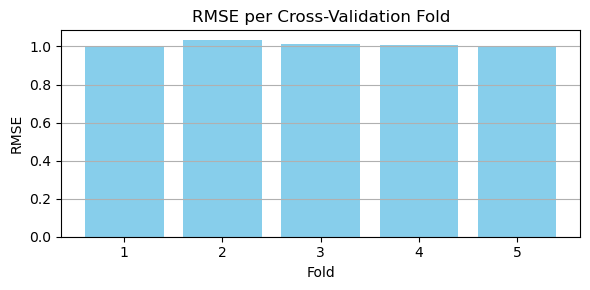

In [18]:
# Initialize model (no feature scaling for Gradient Boosting)
model = RandomForestRegressor(random_state=42)

# Perform 5-fold cross-validation
cv = cross_validate(model, X, y, cv=5, scoring=('r2', 'neg_root_mean_squared_error'))
 
# Convert scores to positive RMSE
rmse_scores = -cv['test_neg_root_mean_squared_error']
r2_scores = cv['test_r2']

# Print mean and std
print(f"Average RMSE: {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")
print(f"Average R²: {r2_scores.mean():.2f} ± {r2_scores.std():.2f}")

# Create DataFrame for plotting
rmse_df = pd.DataFrame({
    'Fold': range(1, 6),
    'RMSE': rmse_scores
})

# Plot RMSE per fold
plt.figure(figsize=(6, 3))
plt.bar(rmse_df['Fold'], rmse_df['RMSE'], color='skyblue')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.title('RMSE per Cross-Validation Fold')
plt.xticks(rmse_df['Fold'])
plt.grid(axis='y')
plt.tight_layout()
plt.show()